<a href="https://colab.research.google.com/github/cookmo/Cook_NEUR265/blob/main/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Morgan Cook
*NEUR265: Introduction to Neural Data Analysis*

**February 19, 2026**

In [1]:
# Importing programs (#2)
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [3]:
# Loading in the data set as a pandas dataframe (#3)
url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq = pd.read_csv(url)

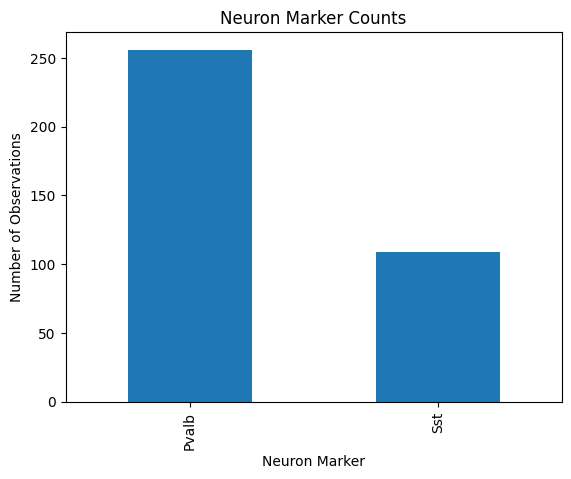

In [15]:
# Making a bar graph of the df value counts (#4)
patch_seq['Marker'].value_counts().plot(kind='bar')

plt.xlabel('Neuron Marker')
plt.ylabel('Number of Observations')
plt.title('Neuron Marker Counts')
plt.show()

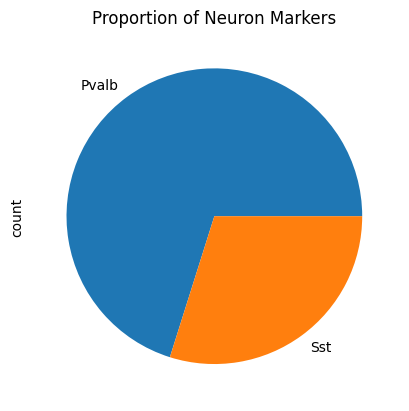

In [13]:
# Making a pie graph of the df value counts (#5)
patch_seq['Marker'].value_counts().plot(kind='pie')

plt.title('Proportion of Neuron Markers')
plt.show()

Text(0, 0.5, 'Fast Trough (mV)')

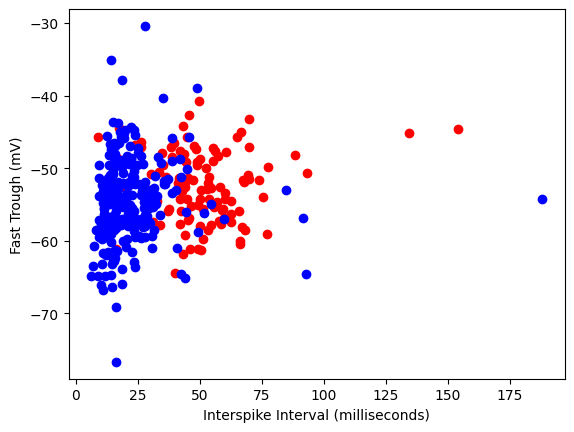

In [28]:
# Use a for loop to make a scatter plot of ISI and Fast Trough values of the data (#6)

df_len = len(patch_seq)

for i in range(df_len):

  if patch_seq.iloc[i,2] == 'Sst':
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")

  else:
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "blue")

plt.xlabel('Interspike Interval (milliseconds)')
plt.ylabel('Fast Trough (mV)')


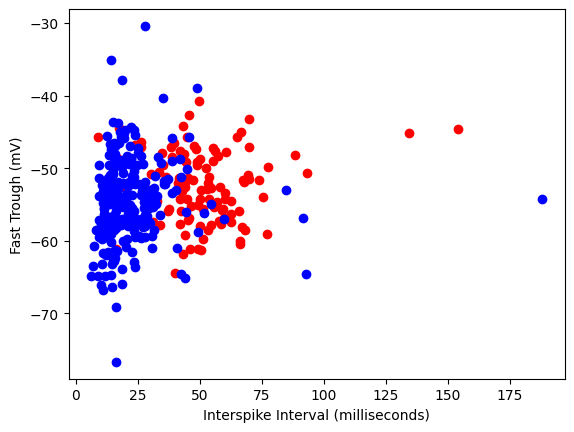

In [30]:
# Defining the function 'patchScatter' (#7)
def patchScatter():
  df_len = len(patch_seq)

  for i in range(df_len):

      if patch_seq.iloc[i,2] == 'Sst':
        plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")

      else:
        plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "blue")

  plt.xlabel('Interspike Interval (milliseconds)')
  plt.ylabel('Fast Trough (mV)')

patchScatter()

In [32]:
# Finding the descriptive stats for the data (#8)
patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


The mean Fast Trough value for Pvalb is more negative than that of the Sst value, meaning that Pvalb neurons have a more negative undershoot following an action potential.

In [33]:
# Finding the skewness of the Fast Trough column of the data (#10)
patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


The fast trough values for both Sst and Pvalb expressing neurons are normally distributed.

In [34]:
# Finding the skewness of the ISI column of the data (#12)
patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


Neither of the fast trough values for Sst or Pvalb expressing neurons are normally distributed.

In [36]:
# Performing a t-test on Fast Trough data (#14)
sst_neurons = patch_seq[patch_seq['Marker']=='Sst']
pvalb_neurons = patch_seq[patch_seq['Marker']=='Pvalb']

stats.ttest_ind(sst_neurons['Fast_Trough'],pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

The undershoot voltage significantly differs between Sst and Pvalb expressing neurons, with a p-value of 0.002.

In [37]:
# Performing a t-test on ISI data (#16)
sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()

stats.ttest_ind(sst, pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

The ISI values significantly differ between Sst and Pvalb expressing neurons, since the p-value is much lower than 0.05, being 2.69e-38.